In [1]:
import torch
import torch.nn as nn

## Implement Partial Cross Entropy Loss

In [35]:
class PCELoss(nn.Module):
    """
    Partial Cross Entropy Loss 
        - evaluates only at labeled points.
    """

    def __init__(self, ignore_index=-1, class_weights=None):
        super().__init__()

        self.ignore_index = ignore_index
        if class_weights is not None:
            self.class_weights = torch.as_tensor(class_weights, dtype=torch.float32)

    def forward(self, logits, point_labels):
        if logits.ndim != 4 or point_labels.ndim != 3:
            raise ValueError("Excepted logints [B, C, H, W] and labels [B, H, W]")

        return nn.functional.cross_entropy(logits,
                                           point_labels.long(),
                                           weight=self.class_weights,
                                           ignore_index=self.ignore_index,
                                           )
        


In [22]:
def make_point_labels(full_mask, fraction, ignore_index=-1):
    device = full_mask.device
    g = torch.Generator(device=device)

    points = torch.full_like(full_mask, ignore_index)
    B, H, W = full_mask.shape

    for b in range(B):
        valid = torch.ones(H, W, dtype=torch.bool, device=device)
        coords = torch.nonzero(valid, as_tuple=False)
        n = max(1, int(round(coords.shape[0] * fraction)))
        idx = torch.randperm(coords.shape[0], generator=g, device=device)[:n]
        selected = coords[idx]
        points[b, selected[:, 0], selected[:, 1]] = full_mask[b, selected[:, 0], selected[:, 1]]
    return points

In [4]:
import numpy as np

def confusion_matrix(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    valid = (y_true >= 0) & (y_true < num_classes)
    np.add.at(cm, (y_true[valid], y_pred[valid]), 1)
    return cm

def segmentation_metrics(y_true, y_pred, num_classes):
    cm = confusion_matrix(y_true, y_pred, num_classes)
    tp = np.diag(cm).astype(float)
    fp = cm.sum(0) - tp
    fn = cm.sum(1) - tp

    iou = tp / np.maximum(tp + fp + fn, 1)
    precision = tp / np.maximum(tp + fp, 1)
    recall = tp / np.maximum(tp + fn, 1)
    f1 = 2 * precision * recall / np.maximum(precision + recall, 1e-12)

    return {
        "mIoU": float(np.mean(iou)),
        "pixel_accuracy": float(tp.sum() / max(cm.sum(), 1)),
        "macro_precision": float(np.mean(precision)),
        "macro_recall": float(np.mean(recall)),
        "macro_f1": float(np.mean(f1)),
        "per_class_iou": iou.tolist(),
    }


In [2]:
from glob import glob

In [14]:
glob("../../../OpenEarthMap/OpenEarthMap_wo_xBD/*")

['../../../OpenEarthMap/OpenEarthMap_wo_xBD/santiago',
 '../../../OpenEarthMap/OpenEarthMap_wo_xBD/mexico_city',
 '../../../OpenEarthMap/OpenEarthMap_wo_xBD/ulaanbaatar',
 '../../../OpenEarthMap/OpenEarthMap_wo_xBD/podlaskie',
 '../../../OpenEarthMap/OpenEarthMap_wo_xBD/chiclayo',
 '../../../OpenEarthMap/OpenEarthMap_wo_xBD/kinshasa',
 '../../../OpenEarthMap/OpenEarthMap_wo_xBD/joplin',
 '../../../OpenEarthMap/OpenEarthMap_wo_xBD/duesseldorf',
 '../../../OpenEarthMap/OpenEarthMap_wo_xBD/gorakhpur',
 '../../../OpenEarthMap/OpenEarthMap_wo_xBD/soriano',
 '../../../OpenEarthMap/OpenEarthMap_wo_xBD/dortmund',
 '../../../OpenEarthMap/OpenEarthMap_wo_xBD/viru',
 '../../../OpenEarthMap/OpenEarthMap_wo_xBD/maputo',
 '../../../OpenEarthMap/OpenEarthMap_wo_xBD/sechura',
 '../../../OpenEarthMap/OpenEarthMap_wo_xBD/saint_louis_du_sud',
 '../../../OpenEarthMap/OpenEarthMap_wo_xBD/muenster',
 '../../../OpenEarthMap/OpenEarthMap_wo_xBD/bogota',
 '../../../OpenEarthMap/OpenEarthMap_wo_xBD/mahe',
 '../

In [3]:
imageDir = "../../../OpenEarthMap/OpenEarthMap_wo_xBD/aachen/images/aachen_1.tif"

RGB
(1000, 1000)


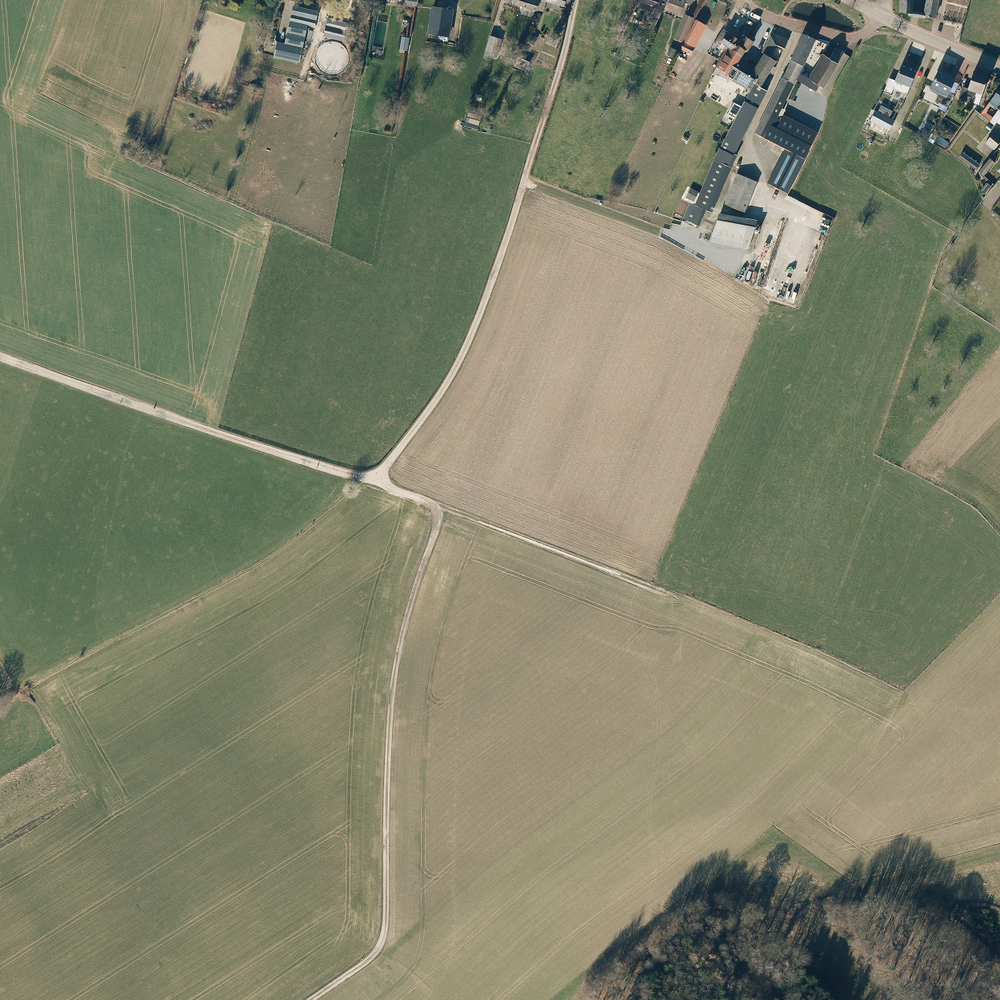

In [4]:
from PIL import Image

img = Image.open(imageDir)

print(img.mode)
print(img.size)
img.show()

In [5]:
labelDir = "../../../OpenEarthMap/OpenEarthMap_wo_xBD/aachen/labels/aachen_1.tif"


L
(1000, 1000)


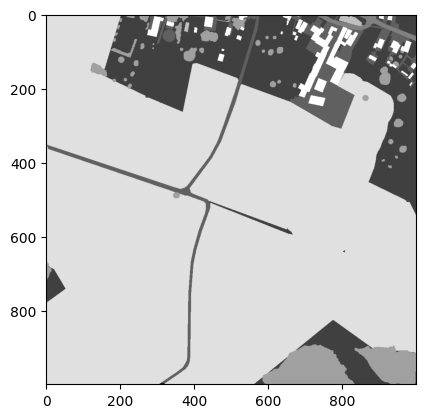

In [6]:
import matplotlib.pyplot as plt

img = Image.open(labelDir)

print(img.mode)
print(img.size)
plt.imshow(img, cmap="gray")

In [8]:
import numpy as np 

img = np.array(img)

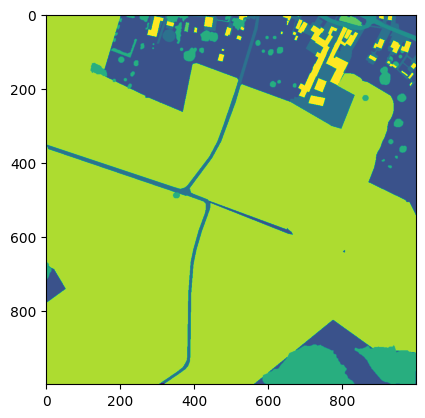

In [9]:
plt.imshow(img)

In [10]:
np.unique(img)

array([0, 2, 3, 4, 5, 6, 7, 8], dtype=uint8)

In [28]:
point_img = make_point_labels(torch.tensor(img).unsqueeze(0), 0.5, 15)

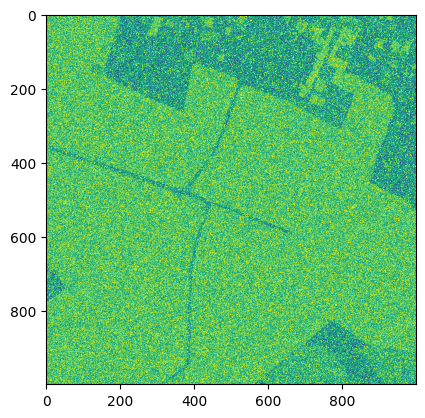

In [29]:
plt.imshow(point_img.squeeze().numpy())

In [25]:
np.unique(point_img.squeeze().numpy())

array([0, 2, 3, 4, 5, 6, 7, 8], dtype=uint8)

In [36]:
import torch
import lightning as L
import segmentation_models_pytorch as smp
# from utils import PCELoss

class UNetLightning(L.LightningModule):

    def __init__(
        self,
        in_channels=3,
        num_classes=7,
        learning_rate=1e-3
    ):
        super().__init__()

        self.save_hyperparameters()

        self.model = smp.Unet(
            encoder_name="resnet34",
            encoder_weights="imagenet",
            in_channels=in_channels,
            classes=num_classes,
        )

        self.loss_fn = PCELoss()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        images, masks = batch

        logits = self(images)

        loss = self.loss_fn(logits, masks)

        self.log(
            "train_loss",
            loss,
            prog_bar=True,
            on_step=False,
            on_epoch=True
        )

        return loss

    def validation_step(self, batch, batch_idx):
        images, masks = batch

        logits = self(images)

        loss = self.loss_fn(logits, masks)

        self.log(
            "val_loss",
            loss,
            prog_bar=True,
            on_epoch=True
        )

        return loss

    def configure_optimizers(self):

        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.hparams.learning_rate,
            weight_decay=1e-4
        )

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=self.trainer.max_epochs
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": scheduler
        }

In [37]:
model = UNetLightning(
    in_channels=3,
    num_classes=7,
    learning_rate=1e-3
)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

In [38]:
trainer = L.Trainer(
    max_epochs=20,
    accelerator="auto",
    devices="auto",
    precision="16-mixed"
)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [48]:
img = Image.open(imageDir)
img = torch.tensor(np.array(img)).permute(2,0,1).float()
img = img.unsqueeze(0).to("cuda")
print(img.shape)
model = model.to("cuda")
pred = model(img)

torch.Size([1, 3, 1000, 1000])


In [49]:
pred.shape

torch.Size([1, 7, 1000, 1000])

In [54]:
npred = pred.detach().cpu().squeeze().permute(1,2,0).argmax(dim=2)
print(npred.shape)

torch.Size([1000, 1000])


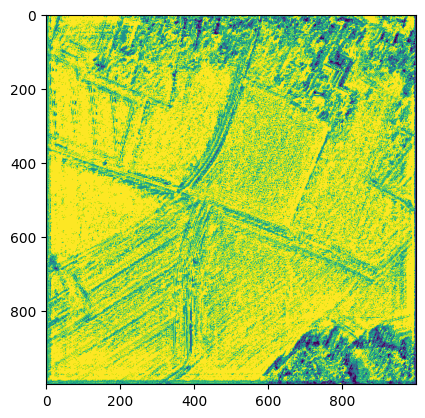

In [55]:
plt.imshow(npred.numpy())